<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_Cultural_Capital_AI_Literacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# [CELL 1 - Dependencies & Qualitative Analytics Setup]
!pip install -q pandas matplotlib seaborn

import json
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any

# Set random seed for reproducible workshop simulation
random.seed(42)

print("AI Literacy Cultural Capital Analysis Toolkit initialized.")
print("Framework: Yosso's Community Cultural Wealth adapted for K-12 AI Education.")

AI Literacy Cultural Capital Analysis Toolkit initialized.
Framework: Yosso's Community Cultural Wealth adapted for K-12 AI Education.


In [12]:
# [CELL 2 - Cultural Capital Taxonomy & Workshop Scenarios]

CULTURAL_CAPITAL_TAXONOMY = {
    "resistant_capital": {
        "definition": "Knowledge and skills fostered through oppositional behaviors that challenge systemic inequities and AI bias.",
        "ai_literacy_manifestation": "Critiquing algorithmic bias in facial recognition, questioning data privacy in school surveillance, and challenging automated grading."
    },
    "communal_capital": {
        "definition": "Cultural knowledge nurtured among family and community members that emphasizes social connection and collective well-being.",
        "ai_literacy_manifestation": "Designing AI tools for local neighborhood support, sharing AI skills with family, and prioritizing collective community needs over individual gain."
    },
    "creative_capital": {
        "definition": "Imaginative and artistic expressions used to reinterpret, appropriate, or reshape technology for self-expression.",
        "ai_literacy_manifestation": "Using generative AI for storytelling, blending traditional cultural art with AI prompts, and re-mixing AI models for community media."
    }
}

AI_LITERACY_WORKSHOP_MODULES = [
    {
        "module_id": "mod_01",
        "topic": "Algorithmic Bias & Surveillance",
        "prompt": "How does automated facial recognition impact your local community?",
        "sample_responses": [
            {
                "text": "It misidentifies people in our neighborhood more often. We should build tools to audit and block biased surveillance cameras.",
                "capital_type": "resistant_capital"
            },
            {
                "text": "We need to teach our elders how these cameras work so everyone in our block stays informed and protected together.",
                "capital_type": "communal_capital"
            }
        ]
    },
    {
        "module_id": "mod_02",
        "topic": "Generative AI & Cultural Storytelling",
        "prompt": "How can we use generative text/image models to represent local heritage?",
        "sample_responses": [
            {
                "text": "I can prompt image models using our community's traditional patterns to create digital murals for local youth centers.",
                "capital_type": "creative_capital"
            },
            {
                "text": "We can build an AI chatbot trained on oral histories recorded by community elders to preserve local languages.",
                "capital_type": "communal_capital"
            }
        ]
    }
]

print("Loaded Cultural Capital Dimensions:")
for k, v in CULTURAL_CAPITAL_TAXONOMY.items():
    print(f" - {k.upper()}: {v['definition']}")

Loaded Cultural Capital Dimensions:
 - RESISTANT_CAPITAL: Knowledge and skills fostered through oppositional behaviors that challenge systemic inequities and AI bias.
 - COMMUNAL_CAPITAL: Cultural knowledge nurtured among family and community members that emphasizes social connection and collective well-being.
 - CREATIVE_CAPITAL: Imaginative and artistic expressions used to reinterpret, appropriate, or reshape technology for self-expression.


In [13]:
# [CELL 3 - Qualitative Dialogue Classifier]

class CulturalCapitalAnalyzer:
    """
    Qualitative analysis probe that categorizes K-12 student workshop dialogue
    into Resistant, Communal, and Creative capital based on Yosso's framework.
    """
    def __init__(self, taxonomy: Dict[str, Any]):
        self.taxonomy = taxonomy

        # Rule-based indicators derived from qualitative coding matrices
        self.indicators = {
            "resistant_capital": ["bias", "surveillance", "unfair", "audit", "block", "protest", "rights", "challenge", "grading"],
            "communal_capital": ["community", "elders", "family", "together", "neighborhood", "share", "protect", "help", "heritage"],
            "creative_capital": ["art", "mural", "storytelling", "patterns", "design", "remix", "music", "style", "prompt"]
        }

    def classify_response(self, text: str) -> Dict[str, Any]:
        text_lower = text.lower()
        scores = {cap: 0 for cap in self.indicators}

        for cap, keywords in self.indicators.items():
            for kw in keywords:
                if kw in text_lower:
                    scores[cap] += 1

        max_score = max(scores.values())
        if max_score > 0:
            dominant_capital = max(scores, key=scores.get)
        else:
            dominant_capital = "general_literacy"

        return {
            "text": text,
            "dominant_capital": dominant_capital,
            "score_breakdown": scores
        }

analyzer = CulturalCapitalAnalyzer(CULTURAL_CAPITAL_TAXONOMY)

# Test probe on sample workshop utterances
sample_utterances = [
    "We should audit how facial recognition tracks people in our neighborhood.",
    "I want to make an AI art mural using traditional weaving patterns with elders.",
    "Our school automated grading is unfair and we need to challenge how data is collected."
]

for utt in sample_utterances:
    res = analyzer.classify_response(utt)
    print(f"Utterance: '{res['text']}'\n -> Classified Capital: {res['dominant_capital'].upper()}\n")

Utterance: 'We should audit how facial recognition tracks people in our neighborhood.'
 -> Classified Capital: RESISTANT_CAPITAL

Utterance: 'I want to make an AI art mural using traditional weaving patterns with elders.'
 -> Classified Capital: CREATIVE_CAPITAL

Utterance: 'Our school automated grading is unfair and we need to challenge how data is collected.'
 -> Classified Capital: RESISTANT_CAPITAL



In [14]:
# [CELL 4 - Co-Design Scenario Log Generator]

def generate_qualitative_workshop_logs(scenarios: List[Dict[str, Any]]) -> pd.DataFrame:
    """
    Formats co-design scenario utterances for qualitative analysis.
    """
    records = []
    for module in scenarios:
        for resp in module["sample_responses"]:
            records.append({
                "module_id": module["module_id"],
                "topic": module["topic"],
                "capital_dimension": resp["capital_type"],
                "sample_dialogue": resp["text"]
            })
    return pd.DataFrame(records)

scenario_logs_df = generate_qualitative_workshop_logs(AI_LITERACY_WORKSHOP_MODULES)
print(f"Generated Scenario Probe Logs: {len(scenario_logs_df)} qualitative prompts across workshop modules.")
print(scenario_logs_df.head().to_string(index=False))

Generated Scenario Probe Logs: 4 qualitative prompts across workshop modules.
module_id                                 topic capital_dimension                                                                                                               sample_dialogue
   mod_01       Algorithmic Bias & Surveillance resistant_capital It misidentifies people in our neighborhood more often. We should build tools to audit and block biased surveillance cameras.
   mod_01       Algorithmic Bias & Surveillance  communal_capital            We need to teach our elders how these cameras work so everyone in our block stays informed and protected together.
   mod_02 Generative AI & Cultural Storytelling  creative_capital        I can prompt image models using our community's traditional patterns to create digital murals for local youth centers.
   mod_02 Generative AI & Cultural Storytelling  communal_capital                We can build an AI chatbot trained on oral histories recorded by communit

In [15]:
# [CELL 5 - Workshop Scenario & Qualitative Classifier Evaluation]

def evaluate_classifier_coverage(scenarios: List[Dict[str, Any]]) -> pd.DataFrame:
    """
    Evaluates classifier coverage across synthetic co-design workshop scenarios.
    Focuses on qualitative categorization accuracy rather than synthetic performance metrics.
    """
    evaluation_logs = []

    for module in scenarios:
        for resp in module["sample_responses"]:
            classification = analyzer.classify_response(resp["text"])
            matched = (classification["dominant_capital"] == resp["capital_type"])

            evaluation_logs.append({
                "module_id": module["module_id"],
                "topic": module["topic"],
                "ground_truth_capital": resp["capital_type"],
                "classified_capital": classification["dominant_capital"],
                "classification_match": matched,
                "text_snippet": resp["text"][:50] + "..."
            })

    return pd.DataFrame(evaluation_logs)

eval_df = evaluate_classifier_coverage(AI_LITERACY_WORKSHOP_MODULES)
print("============================================================")
print("QUALITATIVE CLASSIFIER COVERAGE EVALUATION")
print("============================================================")
print(eval_df[["topic", "ground_truth_capital", "classified_capital", "classification_match"]].to_string(index=False))
print("============================================================")

QUALITATIVE CLASSIFIER COVERAGE EVALUATION
                                topic ground_truth_capital classified_capital  classification_match
      Algorithmic Bias & Surveillance    resistant_capital  resistant_capital                  True
      Algorithmic Bias & Surveillance     communal_capital   communal_capital                  True
Generative AI & Cultural Storytelling     creative_capital   creative_capital                  True
Generative AI & Cultural Storytelling     communal_capital   communal_capital                  True


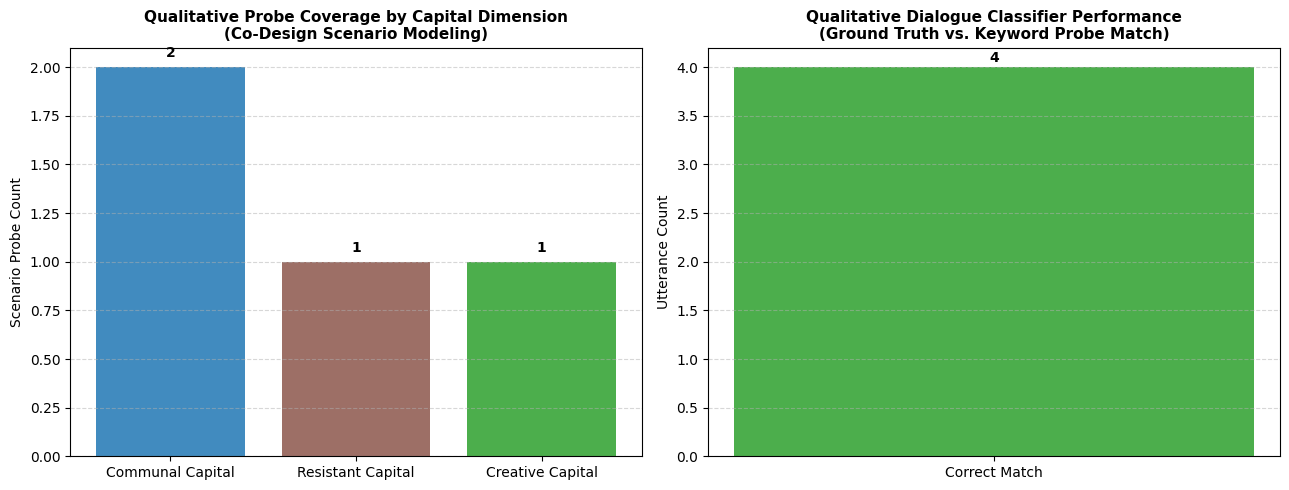

In [17]:
# [CELL 6 - Capital Taxonomy & Scenario Distribution Dashboard]

def plot_cultural_capital_dashboard(df: pd.DataFrame):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # 1. Capital Taxonomy Coverage
    capital_counts = df["ground_truth_capital"].value_counts()
    colors = ['#1f77b4', '#8c564b', '#2ca02c']

    labels = [c.replace("_", " ").title() for c in capital_counts.index]
    ax1.bar(labels, capital_counts.values, color=colors[:len(labels)], alpha=0.85)
    ax1.set_title("Qualitative Probe Coverage by Capital Dimension\n(Co-Design Scenario Modeling)", fontsize=11, fontweight='bold')
    ax1.set_ylabel("Scenario Probe Count", fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    for i, v in enumerate(capital_counts.values):
        ax1.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # 2. Classifier Accuracy Matrix
    match_counts = df["classification_match"].value_counts()
    match_labels = ["Correct Match" if m else "Mismatch" for m in match_counts.index]

    ax2.bar(match_labels, match_counts.values, color=['#2ca02c', '#d62728'], alpha=0.85, width=0.4)
    ax2.set_title("Qualitative Dialogue Classifier Performance\n(Ground Truth vs. Keyword Probe Match)", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Utterance Count", fontsize=10)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    for i, v in enumerate(match_counts.values):
        ax2.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_cultural_capital_dashboard(eval_df)